In [1]:
import os
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon as MplPolygon
from PIL import Image

MASK_PATH = Path("plan_5_mask/plan_5_mask.png")

MASK_FORMAT = "color"

ROOM_MIN_AREA = 120
CONNECTOR_MIN_AREA = 2
MATCH_TOLERANCE = 8
CONTOUR_MODE = "poly"  # "poly" or "bbox"
SEAL_KSIZE = "auto"    # "auto" or one integer, e.g. 7

FUSE_KERNEL_SIZE = 5
BRIDGE_TO_WALLS = True
BRIDGE_MAX_GAP = 20
BRIDGE_TOUCH_RADIUS = 2
BRIDGE_MIN_PIXELS = 6

KEEP_OUTSIDE_EDGES = True
SAMPLE_ID = MASK_PATH.stem
OUTDIR = MASK_PATH.with_suffix("")
OUTDIR.mkdir(parents=True, exist_ok=True)
OUT_BASE = OUTDIR / MASK_PATH.stem

print(f"Mask path: {MASK_PATH.resolve()}")
print(f"Output base: {OUT_BASE.resolve()}")

BACKGROUND_ID = 0
WALL_ID = 1
DOOR_ID = 2
WINDOW_ID = 3
OUTSIDE_ID = -1

LABELS = {0: "background", 1: "wall", 2: "door", 3: "window"}
CONNECTOR_IDS = {DOOR_ID, WINDOW_ID}
BARRIER_IDS = [WALL_ID, DOOR_ID, WINDOW_ID]

COLOR_MAP = {
    0: (200, 200, 200),
    1: (40, 40, 40),
    2: (160, 82, 45),
    3: (135, 206, 250),
}

CLASS_COLORS = np.array([COLOR_MAP[i] for i in range(4)], dtype=np.float32) / 255.0
CLASS_CMAP = ListedColormap(CLASS_COLORS)
CLASS_NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], CLASS_CMAP.N)


Mask path: /Users/butchiadari/Desktop/Synthetic_Data_Gen/plan_5_mask/plan_5_mask.png
Output base: /Users/butchiadari/Desktop/Synthetic_Data_Gen/plan_5_mask/plan_5_mask/plan_5_mask


In [2]:
def print_class_histogram(mask, tag="classes"):
    ids, counts = np.unique(mask, return_counts=True)
    total = mask.size
    rows = []
    for cls_id, count in zip(ids, counts):
        rows.append({
            "id": int(cls_id),
            "class": LABELS.get(int(cls_id), str(cls_id)),
            "pixels": int(count),
            "percent": round(100 * int(count) / total, 3),
        })
    df = pd.DataFrame(rows)
    print(f"[{tag}] shape={mask.shape}, total_pixels={total}")
    display(df)
    return df


def mask_to_rgb(mask, color_map=COLOR_MAP):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), np.uint8)
    for cls, color in color_map.items():
        rgb[mask == cls] = color
    return rgb


def show_label_mask(mask, title="mask", figsize=(8, 8), alpha=1.0):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mask, cmap=CLASS_CMAP, norm=CLASS_NORM, interpolation="nearest", alpha=alpha)
    handles = [Line2D([0], [0], marker="s", linestyle="", color=CLASS_COLORS[i], label=f"{i}: {LABELS[i]}") for i in range(4)]
    ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
    ax.set_title(title)
    ax.axis("off")
    plt.show()
    return fig


def show_binary(mask, title="binary mask", figsize=(8, 8)):  
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mask, cmap="gray", interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    plt.show()
    return fig


def show_components(label_map, title="components", background=-1, figsize=(8, 8)):
    data = label_map.astype(float).copy()
    data[label_map == background] = np.nan
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data, cmap="tab20", interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()
    return fig


def overlay_room_contours(mask, rooms, title="rooms", figsize=(9, 9)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mask_to_rgb(mask), interpolation="nearest")
    cmap = plt.colormaps["tab20"]
    for room in rooms:
        contour = room.get("contour")
        cx, cy = room["centroid_px"]
        color = cmap(room["id"] % 20)
        if contour and len(contour) >= 3:
            ax.add_patch(MplPolygon(contour, closed=True, facecolor=color, edgecolor="black", alpha=0.35, linewidth=1.2))
        ax.scatter([cx], [cy], s=180, color=color, edgecolors="black", linewidths=1.1, zorder=5)
        ax.text(cx, cy, str(room["id"]), ha="center", va="center", fontsize=8, fontweight="bold", zorder=6)
    ax.set_title(title)
    ax.axis("off")
    plt.show()
    return fig


def overlay_connectors(mask, connectors, title="connectors", figsize=(9, 9)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mask_to_rgb(mask), interpolation="nearest")
    colors = {DOOR_ID: "#ff7f0e", WINDOW_ID: "#1f78ff"}
    for conn in connectors:
        cx, cy = conn["centroid_px"]
        color = colors.get(conn["label_id"], "white")
        contour = conn.get("contour")
        if contour and len(contour) >= 3:
            ax.add_patch(MplPolygon(contour, closed=True, facecolor="none", edgecolor=color, linewidth=2.0))
        ax.scatter([cx], [cy], s=70, marker="D", color=color, edgecolors="white", linewidths=1, zorder=5)
        ax.text(cx + 3, cy + 3, f"{conn['id']}:{conn['type']}", color=color, fontsize=8, weight="bold")
    ax.set_title(title)
    ax.axis("off")
    plt.show()
    return fig


In [3]:
def load_label_mask(path):
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(path)
    if img.ndim == 3:
        img = img[..., 0]
    return img.astype(np.int32)


def load_color_mask_exact(path, color_map=COLOR_MAP):
    rgb = np.array(Image.open(path).convert("RGB"))
    label = np.zeros(rgb.shape[:2], np.int32)
    unmatched = np.ones(rgb.shape[:2], dtype=bool)
    for cls, color in color_map.items():
        hit = np.all(rgb == np.array(color, np.uint8), axis=-1)
        label[hit] = cls
        unmatched &= ~hit
    return label, unmatched, rgb


Unmatched RGB pixels: 0


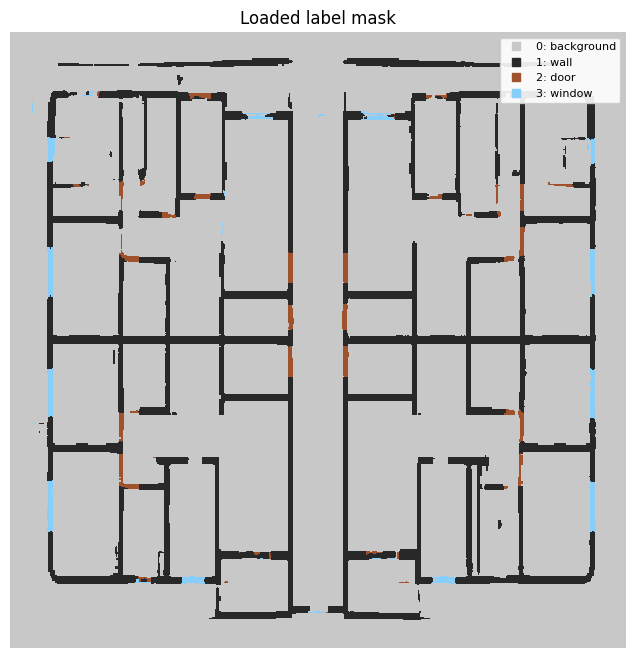

In [4]:
if MASK_FORMAT == "color":
    mask, unmatched_pixels, raw_rgb = load_color_mask_exact(MASK_PATH)
    print(f"Unmatched RGB pixels: {int(unmatched_pixels.sum())}")
    if unmatched_pixels.any():
        show_binary(unmatched_pixels, "Pixels that did not match COLOR_MAP exactly")
elif MASK_FORMAT == "label":
    mask = load_label_mask(MASK_PATH)
    raw_rgb = None
else:
    raise ValueError("MASK_FORMAT must be 'color' or 'label'")

fig = show_label_mask(mask, "Loaded label mask")


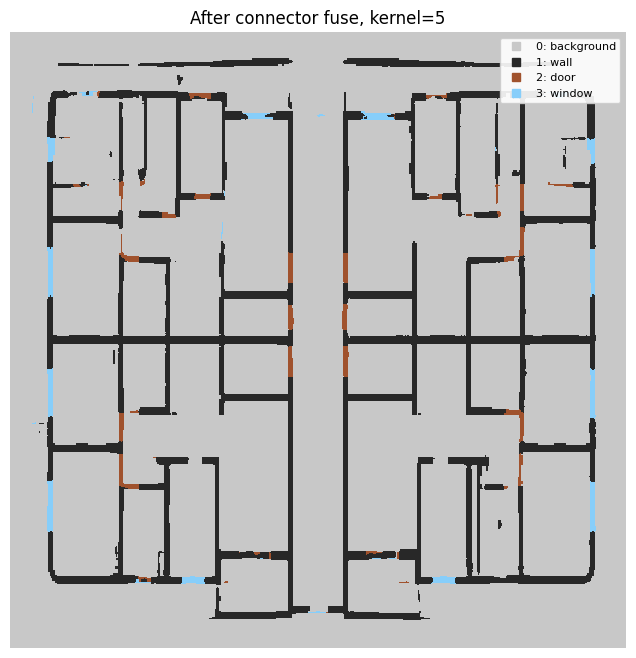

In [5]:
def fuse_connectors(mask, fuse_kernel_size=5):
    cleaned = mask.astype(np.int32).copy()
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (fuse_kernel_size, fuse_kernel_size))
    debug = {}
    for cid in sorted(CONNECTOR_IDS):
        before = (cleaned == cid).astype(np.uint8)
        fused = cv2.morphologyEx(before, cv2.MORPH_CLOSE, kernel)
        added = (fused > 0) & (cleaned == BACKGROUND_ID)
        cleaned[added] = cid
        debug[cid] = {"before": before, "fused": fused, "added": added}
    return cleaned, debug

fused_mask, fuse_debug = fuse_connectors(mask, FUSE_KERNEL_SIZE)
fig = show_label_mask(fused_mask, f"After connector fuse, kernel={FUSE_KERNEL_SIZE}")

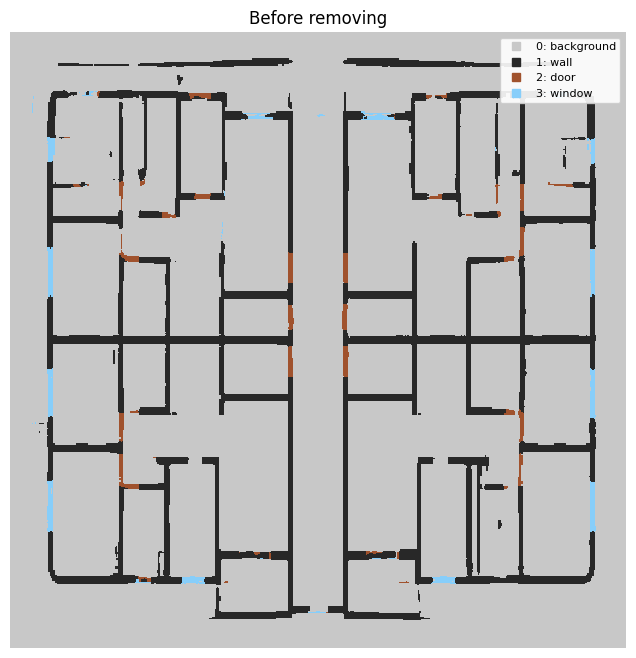

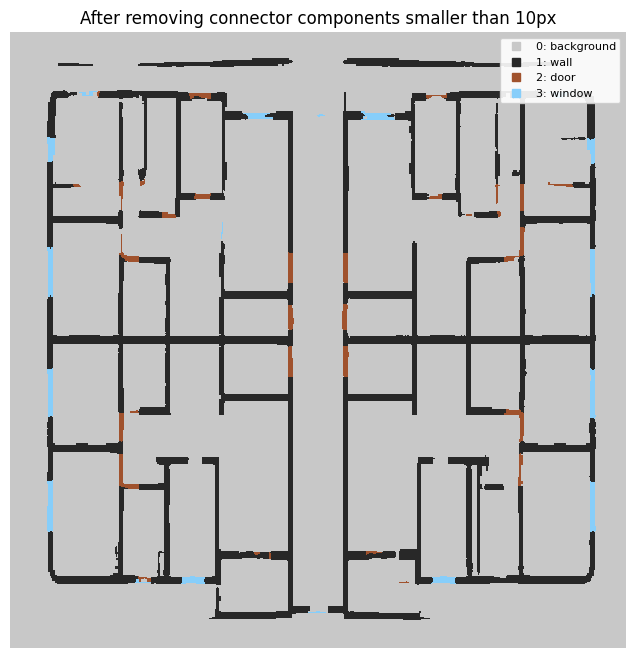

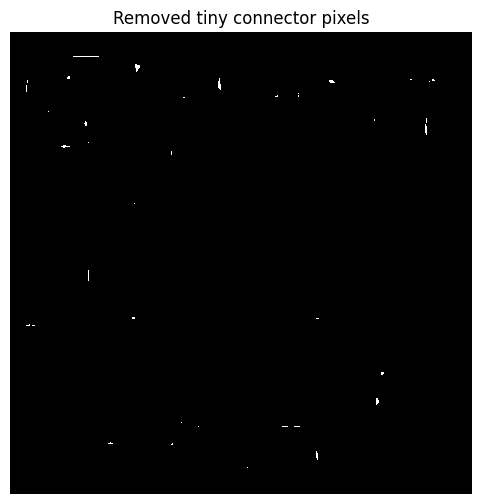

In [7]:
CONNECTOR_MIN_AREA = 10

def remove_tiny_connectors(mask, connector_min_area=2):
    cleaned = mask.astype(np.int32).copy()
    removed = np.zeros_like(cleaned, dtype=bool)
    summary = []
    for cid in sorted(CONNECTOR_IDS):
        layer = (cleaned == cid).astype(np.uint8)
        n, lbl, stats, cent = cv2.connectedComponentsWithStats(layer, 8)
        for i in range(1, n):
            area = int(stats[i, cv2.CC_STAT_AREA])
            keep = area >= connector_min_area
            summary.append({"class_id": cid, "class": LABELS[cid], "component": i, "area_px": area, "kept": keep})
            if not keep:
                drop = lbl == i
                cleaned[drop] = BACKGROUND_ID
                removed |= drop

    # removes wall
    for cid in sorted([1]):
        layer = (cleaned == cid).astype(np.uint8)
        n, lbl, stats, cent = cv2.connectedComponentsWithStats(layer, 8)
        for i in range(1, n):
            area = int(stats[i, cv2.CC_STAT_AREA])
            keep = area >= 30
            summary.append({"class_id": cid, "class": LABELS[cid], "component": i, "area_px": area, "kept": keep})
            if not keep:
                drop = lbl == i
                cleaned[drop] = BACKGROUND_ID
                removed |= drop
    
    return cleaned, removed, pd.DataFrame(summary)

despecked_mask, removed_connector_specks, connector_component_table = remove_tiny_connectors(fused_mask, CONNECTOR_MIN_AREA)
show_label_mask(mask, f"Before removing")
show_label_mask(despecked_mask, f"After removing connector components smaller than {CONNECTOR_MIN_AREA}px")
fig = show_binary(removed_connector_specks, "Removed tiny connector pixels", figsize=(6, 6))


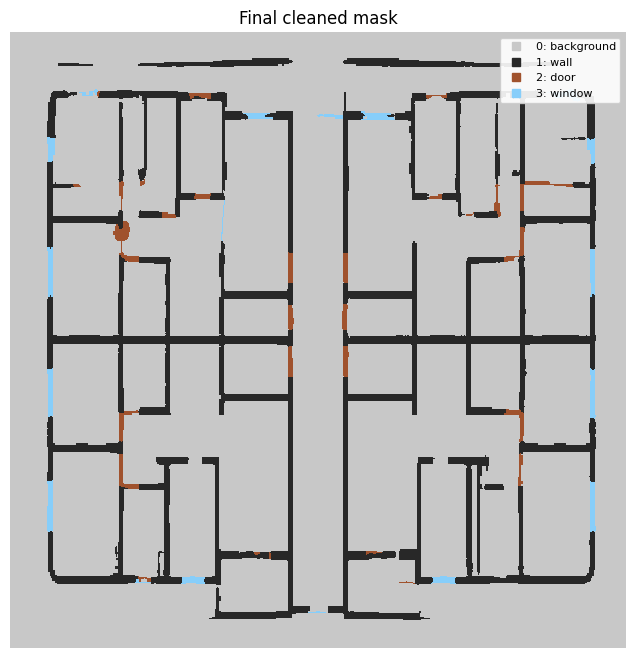

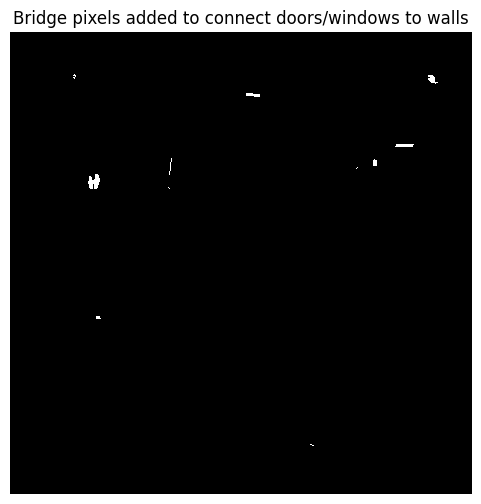

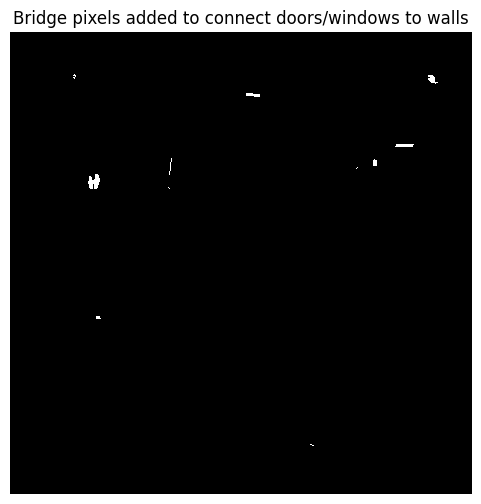

In [8]:
def connect_connectors_to_walls(cleaned, max_gap=20, touch_radius=2, min_pixels=6):
    cleaned = cleaned.astype(np.int32).copy()
    H, W = cleaned.shape
    wall = (cleaned == WALL_ID).astype(np.uint8)
    bridge_mask = np.zeros_like(cleaned, dtype=bool)
    bridge_rows = []

    for cid in sorted(CONNECTOR_IDS):
        n, lbl, stats, _ = cv2.connectedComponentsWithStats((cleaned == cid).astype(np.uint8), 8)
        for i in range(1, n):
            area = int(stats[i, cv2.CC_STAT_AREA])
            if area < min_pixels:
                bridge_rows.append({"class": LABELS[cid], "component": i, "area_px": area, "status": "too_small", "bridges": 0})
                continue

            ys, xs = np.where(lbl == i)
            pts = np.column_stack([xs, ys]).astype(np.float64)
            center = pts.mean(0)
            cov = np.cov((pts - center).T)
            evals, evecs = np.linalg.eigh(cov)
            axis = evecs[:, int(np.argmax(evals))]
            axis = axis / (np.linalg.norm(axis) + 1e-9)
            minor = evecs[:, int(np.argmin(evals))]
            proj_major = (pts - center) @ axis
            proj_minor = (pts - center) @ minor
            thick = max(1, int(round(proj_minor.max() - proj_minor.min())))
            half = thick // 2 + 2
            perp = np.array([-axis[1], axis[0]])
            tips = [(pts[int(np.argmax(proj_major))], +1.0), (pts[int(np.argmin(proj_major))], -1.0)]

            component_bridges = 0
            for tip, sign in tips:
                u = axis * sign
                tx, ty = int(round(tip[0])), int(round(tip[1]))
                y0, y1 = max(0, ty - touch_radius), min(H, ty + touch_radius + 1)
                x0, x1 = max(0, tx - touch_radius), min(W, tx + touch_radius + 1)
                if wall[y0:y1, x0:x1].any():
                    continue

                hit = None
                for step in range(1, max_gap + 1):
                    base = tip + u * step
                    for t in range(-half, half + 1):
                        px = int(round(base[0] + perp[0] * t))
                        py = int(round(base[1] + perp[1] * t))
                        if 0 <= px < W and 0 <= py < H and wall[py, px]:
                            hit = (px, py)
                            break
                    if hit is not None:
                        break

                if hit is not None:
                    line = np.zeros((H, W), np.uint8)
                    cv2.line(line, (tx, ty), hit, 1, thickness=thick)
                    added = (line > 0) & (cleaned == BACKGROUND_ID)
                    cleaned[added] = cid
                    bridge_mask |= added
                    component_bridges += 1

            bridge_rows.append({"class": LABELS[cid], "component": i, "area_px": area, "status": "processed", "bridges": component_bridges})

    return cleaned, bridge_mask, pd.DataFrame(bridge_rows)

if BRIDGE_TO_WALLS:
    cleaned_mask, bridge_added_mask, bridge_table = connect_connectors_to_walls(
        despecked_mask,
        max_gap=BRIDGE_MAX_GAP,
        touch_radius=BRIDGE_TOUCH_RADIUS,
        min_pixels=BRIDGE_MIN_PIXELS,
    )
else:
    cleaned_mask = despecked_mask.copy()
    bridge_added_mask = np.zeros_like(cleaned_mask, dtype=bool)
    bridge_table = pd.DataFrame()

# display(bridge_table)
# print_class_histogram(cleaned_mask, "final cleaned mask")
show_label_mask(cleaned_mask, "Final cleaned mask")
show_binary(bridge_added_mask, "Bridge pixels added to connect doors/windows to walls", figsize=(6, 6))


In [9]:
def bbox4(x, y, w, h):
    return [[int(x), int(y)], [int(x + w), int(y)], [int(x + w), int(y + h)], [int(x), int(y + h)]]


def bbox_contour(blob):
    ys, xs = np.where(blob)
    if xs.size == 0:
        return None
    x0, y0, x1, y1 = int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())
    return [[x0, y0], [x1, y0], [x1, y1], [x0, y1]]


def poly_contour(blob, max_pts=24, min_pts=4):
    cnts, _ = cv2.findContours(blob.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(c, True)
    if peri == 0:
        return None
    eps = 0.01 * peri
    approx = cv2.approxPolyDP(c, eps, True)
    while len(approx) > max_pts and eps < 0.05 * peri:
        eps *= 1.3
        nxt = cv2.approxPolyDP(c, eps, True)
        if len(nxt) < min_pts:
            break
        approx = nxt
    return approx.reshape(-1, 2).tolist()


In [10]:
def extract_rooms_debug(cleaned, min_area=120, contour_mode="poly", seal_ksize=7):
    H, W = cleaned.shape
    barrier_before = np.isin(cleaned, BARRIER_IDS).astype(np.uint8)
    barrier = barrier_before.copy()
    if seal_ksize and seal_ksize > 1:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (seal_ksize, seal_ksize))
        barrier = cv2.morphologyEx(barrier, cv2.MORPH_CLOSE, k)

    free = (barrier == 0).astype(np.uint8)
    n, lbl, stats, cent = cv2.connectedComponentsWithStats(free, connectivity=4)

    outside_cc = set()
    for i in range(1, n):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        if x == 0 or y == 0 or x + w >= W or y + h >= H:
            outside_cc.add(i)
    if not outside_cc and n > 1:
        outside_cc.add(max(range(1, n), key=lambda i: stats[i, cv2.CC_STAT_AREA]))

    contour_fn = bbox_contour if contour_mode == "bbox" else poly_contour
    nodes = []
    room_label_map = np.full((H, W), -1, np.int32)
    component_rows = []
    nid = 0
    for i in range(1, n):
        area = int(stats[i, cv2.CC_STAT_AREA])
        is_outside = i in outside_cc
        keep = (not is_outside) and area >= min_area
        component_rows.append({
            "free_component": i,
            "area_px": area,
            "bbox_x": int(stats[i, cv2.CC_STAT_LEFT]),
            "bbox_y": int(stats[i, cv2.CC_STAT_TOP]),
            "bbox_w": int(stats[i, cv2.CC_STAT_WIDTH]),
            "bbox_h": int(stats[i, cv2.CC_STAT_HEIGHT]),
            "is_outside": is_outside,
            "kept_as_room": keep,
        })
        if not keep:
            continue
        blob = lbl == i
        contour = contour_fn(blob)
        if contour is None or len(contour) < 3:
            continue
        cx, cy = cent[i]
        nodes.append({
            "id": nid,
            "name": f"room_{nid}",
            "area_px": area,
            "centroid_px": [float(cx), float(cy)],
            "bbox_px": bbox4(stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]),
            "contour": contour,
        })
        room_label_map[blob] = nid
        nid += 1

    outside_mask = np.isin(lbl, list(outside_cc))
    debug = {
        "barrier_before": barrier_before,
        "barrier": barrier,
        "free": free,
        "free_component_map": lbl,
        "outside_component_ids": sorted(outside_cc),
        "component_table": pd.DataFrame(component_rows),
    }
    return nodes, room_label_map, outside_mask, debug


In [11]:
# ============================================================
# 10) Seal sweep - try multiple seal kernels and choose the one with most rooms
# ============================================================
seal_list = [SEAL_KSIZE] if SEAL_KSIZE != "auto" else [3, 5, 7, 9, 13, 17, 21]
seal_results = []
room_results_by_seal = {}

for seal in seal_list:
    rooms_s, room_label_map_s, outside_mask_s, room_debug_s = extract_rooms_debug(
        cleaned_mask,
        min_area=ROOM_MIN_AREA,
        contour_mode=CONTOUR_MODE,
        seal_ksize=seal,
    )
    seal_results.append({
        "seal_ksize": seal,
        "rooms": len(rooms_s),
        "free_components": int(room_debug_s["free_component_map"].max()),
        "outside_components": len(room_debug_s["outside_component_ids"]),
    })
    room_results_by_seal[seal] = (rooms_s, room_label_map_s, outside_mask_s, room_debug_s)

seal_table = pd.DataFrame(seal_results)
display(seal_table)

best_seal = max(seal_list, key=lambda s: len(room_results_by_seal[s][0]))
rooms, room_label_map, outside_mask, room_debug = room_results_by_seal[best_seal]
print(f"Best seal kernel: {best_seal}; rooms found: {len(rooms)}")

,seal_ksize,rooms,free_components,outside_components
0,3,24,27,1
1,5,25,26,1
2,7,25,26,1
3,9,26,27,1
4,13,26,27,1
5,17,31,32,1
6,21,31,32,1


Best seal kernel: 17; rooms found: 31


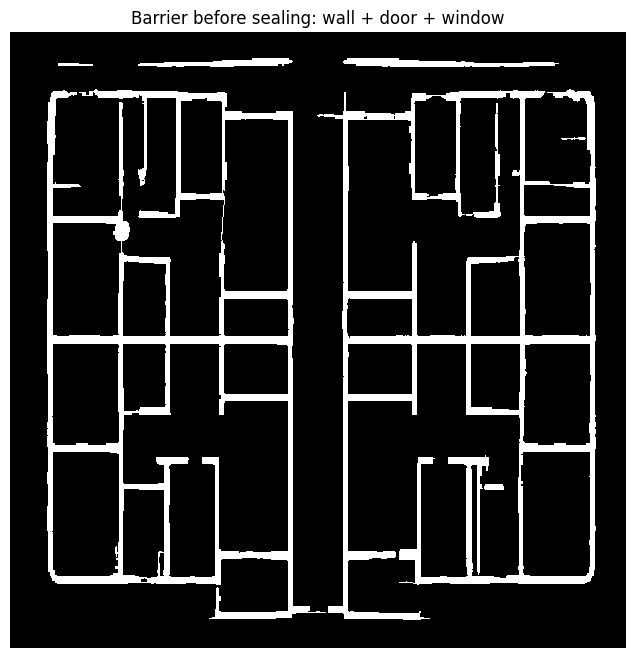

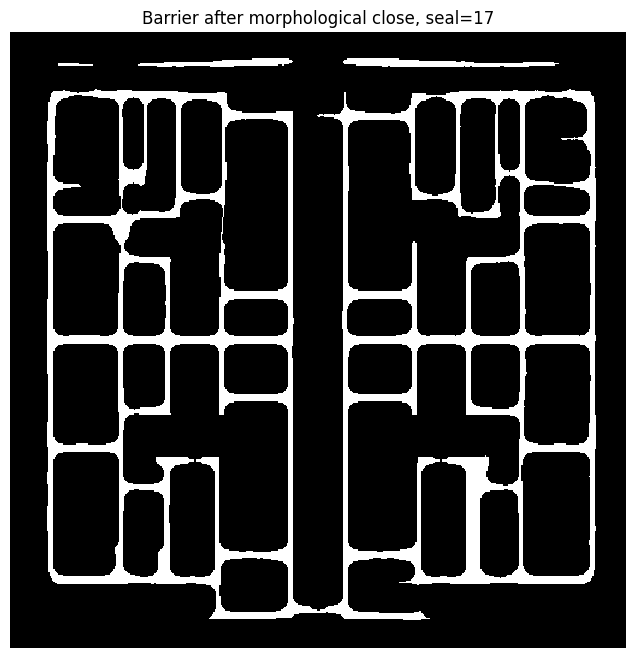

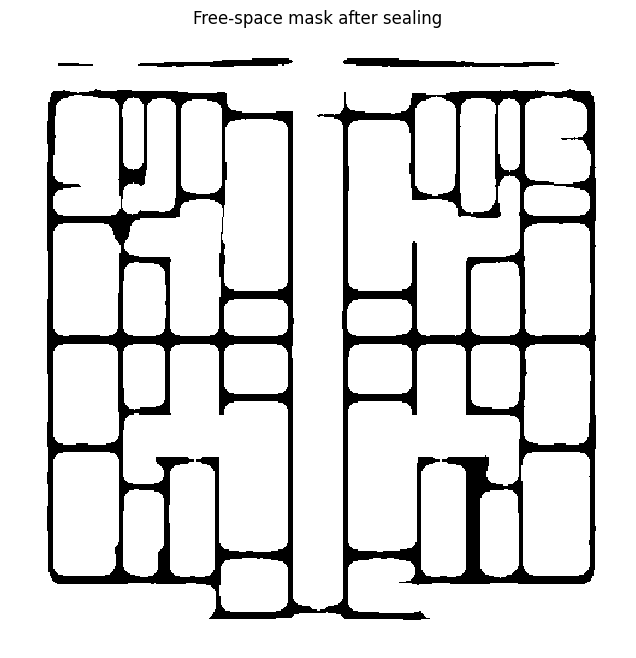

,free_component,area_px,bbox_x,bbox_y,bbox_w,bbox_h,is_outside,kept_as_room
0,1,92090,0,0,512,512,True,False
24,25,16316,281,259,143,194,False,True
21,22,16285,94,259,137,194,False,True
10,11,13972,281,73,143,180,False,True
9,10,7404,176,72,55,143,False,True
28,29,5686,425,349,57,103,False,True
12,13,5635,95,139,82,114,False,True
27,28,5496,36,349,55,103,False,True
1,2,5201,36,52,56,101,False,True
14,15,4993,427,159,56,94,False,True


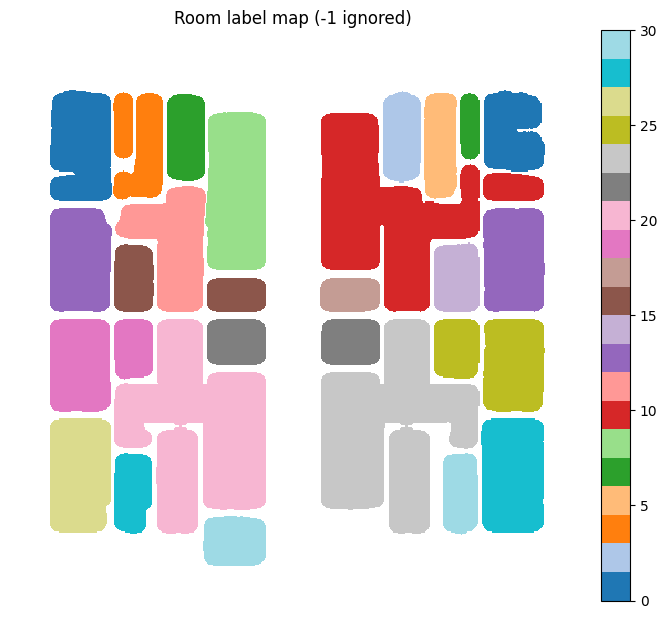

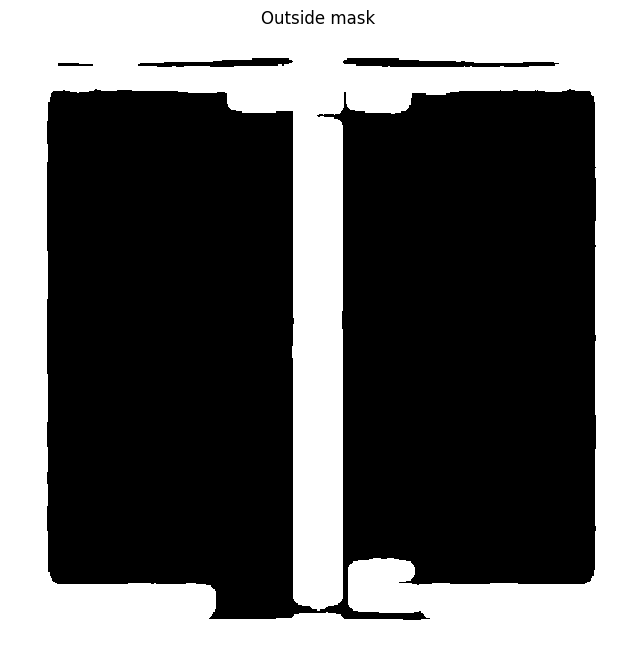

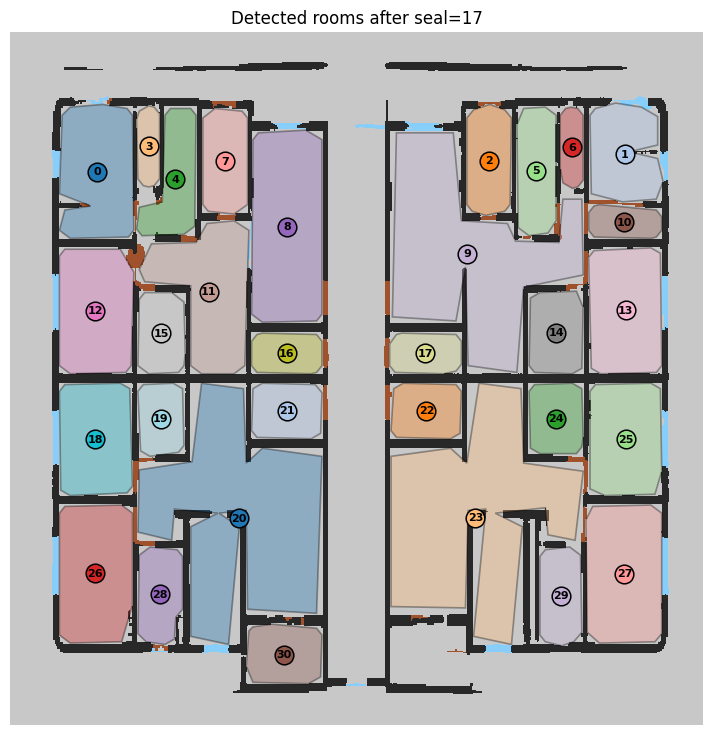

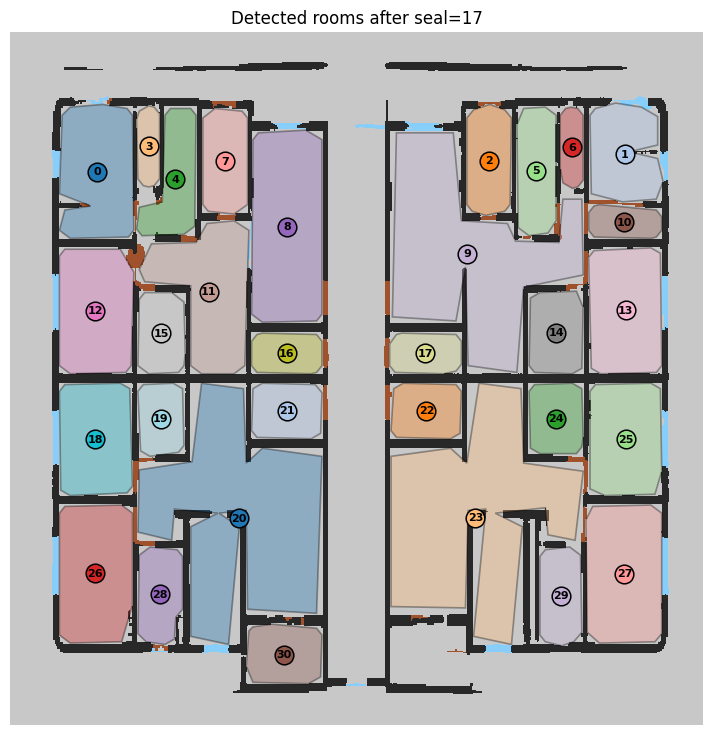

In [12]:
# ============================================================
# 11) Plot selected room-extraction intermediates
# ============================================================
show_binary(room_debug["barrier_before"], "Barrier before sealing: wall + door + window")
show_binary(room_debug["barrier"], f"Barrier after morphological close, seal={best_seal}")
show_binary(room_debug["free"], "Free-space mask after sealing")
display(room_debug["component_table"].sort_values("area_px", ascending=False).head(50))
show_components(room_label_map, "Room label map (-1 ignored)")
show_binary(outside_mask, "Outside mask")
overlay_room_contours(cleaned_mask, rooms, f"Detected rooms after seal={best_seal}")


,class_id,class,component,area_px,kept
12,2,door,13,246,True
5,2,door,6,172,True
20,2,door,21,129,True
22,2,door,23,127,True
13,2,door,14,119,True
21,2,door,22,114,True
19,2,door,20,107,True
14,2,door,15,101,True
15,2,door,16,99,True
18,2,door,19,93,True


,id,type,label_id,centroid_px
0,0,door,2,"[72.9, 50.7]"
1,1,door,2,"[158.375, 52.453125]"
2,2,door,2,"[354.02702702702703, 52.75675675675676]"
3,3,door,2,"[109.46666666666667, 124.86666666666666]"
4,4,door,2,"[92.18867924528301, 132.54716981132074]"
5,5,door,2,"[437.6279069767442, 130.22093023255815]"
6,6,door,2,"[54.705882352941174, 127.05882352941177]"
7,7,door,2,"[404.44444444444446, 140.45679012345678]"
8,8,door,2,"[159.27777777777777, 136.40740740740742]"
9,9,door,2,"[353.48571428571427, 136.85714285714286]"


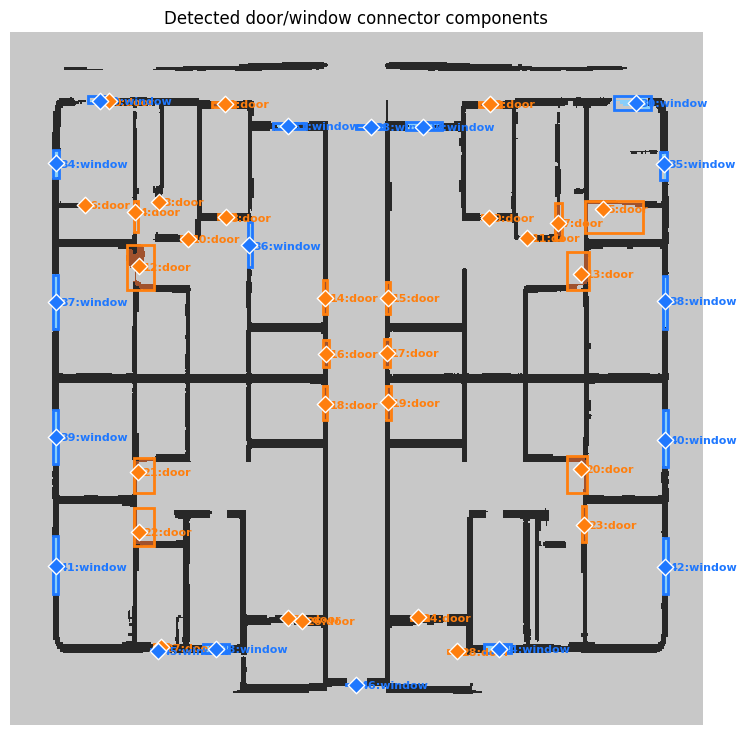

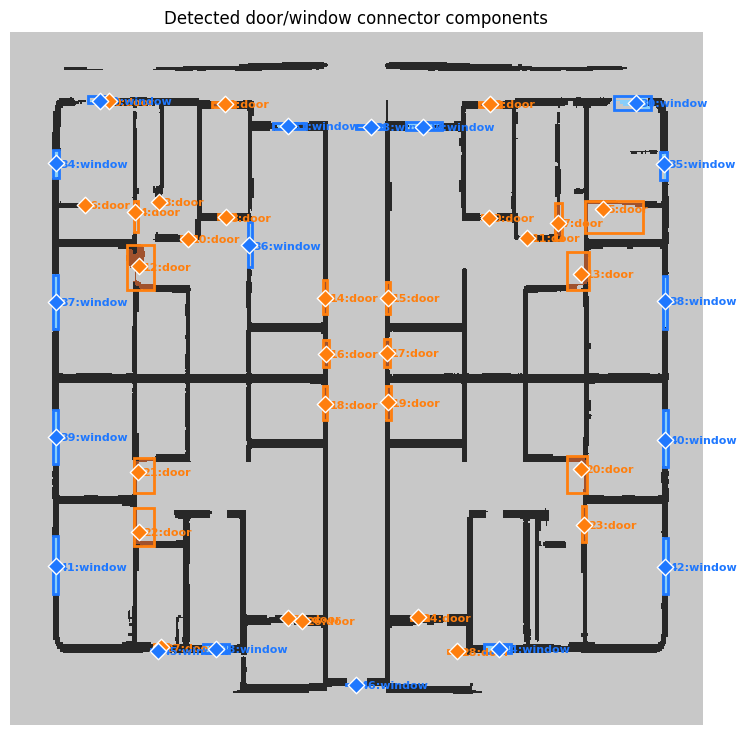

In [13]:
# ============================================================
# 12) Connector extraction
# ============================================================
def extract_connectors_debug(cleaned, min_area=2):
    conns = []
    rows = []
    cnt = 0
    for cls in sorted(CONNECTOR_IDS):
        layer = (cleaned == cls).astype(np.uint8)
        n, lbl, stats, cent = cv2.connectedComponentsWithStats(layer, 8)
        for i in range(1, n):
            area = int(stats[i, cv2.CC_STAT_AREA])
            keep = area >= min_area
            rows.append({"class_id": cls, "class": LABELS[cls], "component": i, "area_px": area, "kept": keep})
            if not keep:
                continue
            blob = lbl == i
            contour = bbox_contour(blob)
            if contour is None:
                continue
            cx, cy = cent[i]
            conns.append({
                "id": cnt,
                "type": LABELS[cls],
                "label_id": int(cls),
                "centroid_px": [float(cx), float(cy)],
                "contour": contour,
                "_mask": blob,
            })
            cnt += 1
    return conns, pd.DataFrame(rows)

connectors, connector_extract_table = extract_connectors_debug(cleaned_mask, CONNECTOR_MIN_AREA)
display(connector_extract_table.sort_values(["class_id", "area_px"], ascending=[True, False]).head(100))
display(pd.DataFrame([{k: v for k, v in c.items() if k != "_mask" and k != "contour"} for c in connectors]))
overlay_connectors(cleaned_mask, connectors, "Detected door/window connector components")


In [37]:
# ============================================================
# 13) Build room-connector edges
# ============================================================
def touching_rooms(conn_mask, room_label_map, outside_mask, tolerance):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * tolerance + 1, 2 * tolerance + 1))
    grown = cv2.dilate(conn_mask.astype(np.uint8), k).astype(bool)
    touches_outside = bool((grown & outside_mask).any())
    region = room_label_map[grown]
    region = region[region >= 0]
    if region.size == 0:
        return [], touches_outside, grown
    ids, counts = np.unique(region, return_counts=True)
    ordered = ids[np.argsort(-counts)].tolist()
    return ordered, touches_outside, grown


def build_edges_debug(room_label_map, outside_mask, connectors, tolerance):
    edges = []
    rows = []
    grown_by_connector = {}
    for eid, c in enumerate(connectors):
        rooms_touched, outside, grown = touching_rooms(c["_mask"], room_label_map, outside_mask, tolerance)
        grown_by_connector[eid] = grown
        edge = {
            "id": eid,
            "type": c["type"],
            "label_id": c["label_id"],
            "centroid_px": c["centroid_px"],
            "contour": c["contour"],
            "from": None,
            "to": None,
        }
        if len(rooms_touched) >= 2:
            edge["from"], edge["to"] = int(rooms_touched[0]), int(rooms_touched[1])
        elif len(rooms_touched) == 1:
            edge["from"] = int(rooms_touched[0])
            edge["to"] = OUTSIDE_ID if outside else None
        edges.append(edge)
        rows.append({
            "edge_id": eid,
            "type": c["type"],
            "rooms_touched_ordered": rooms_touched,
            "touches_outside": outside,
            "from": edge["from"],
            "to": edge["to"],
        })
    return edges, pd.DataFrame(rows), grown_by_connector

effective_tolerance = max(MATCH_TOLERANCE, int(best_seal) // 2 + 4)
edges, edge_table, grown_by_connector = build_edges_debug(room_label_map, outside_mask, connectors, effective_tolerance)
print(f"Effective connector-room tolerance: {effective_tolerance}")
display(edge_table)


Effective connector-room tolerance: 14


,edge_id,type,rooms_touched_ordered,touches_outside,from,to
0,0,door,"[1, 5, 6, 0]",False,1,5.0
1,1,door,"[3, 7, 4, 8]",False,3,7.0
2,2,door,"[6, 5, 1]",False,6,5.0
3,3,door,"[8, 4, 3]",False,8,4.0
4,4,door,"[5, 0, 1]",False,5,0.0
5,5,door,"[9, 5]",False,9,5.0
6,6,door,"[9, 8, 11]",False,9,8.0
7,7,door,"[11, 9]",False,11,9.0
8,8,door,[11],False,11,NaN
9,9,door,"[9, 10, 13]",False,9,10.0


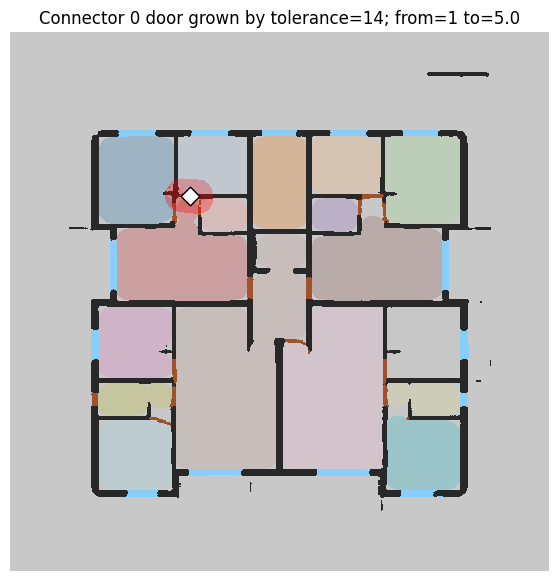

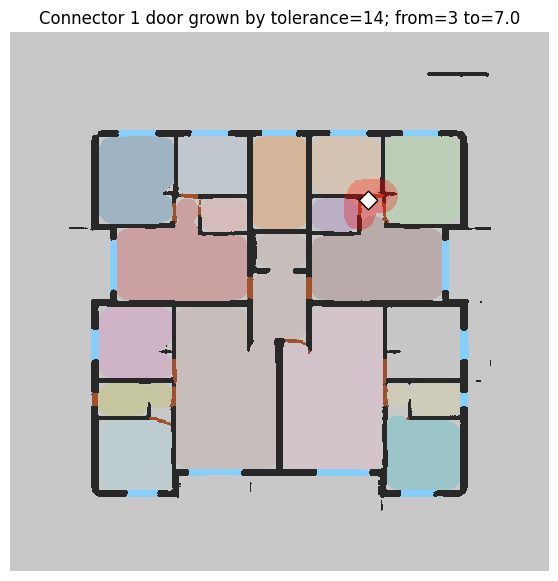

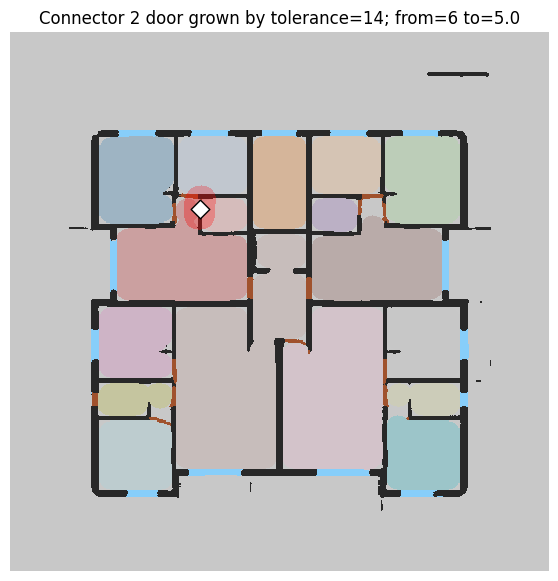

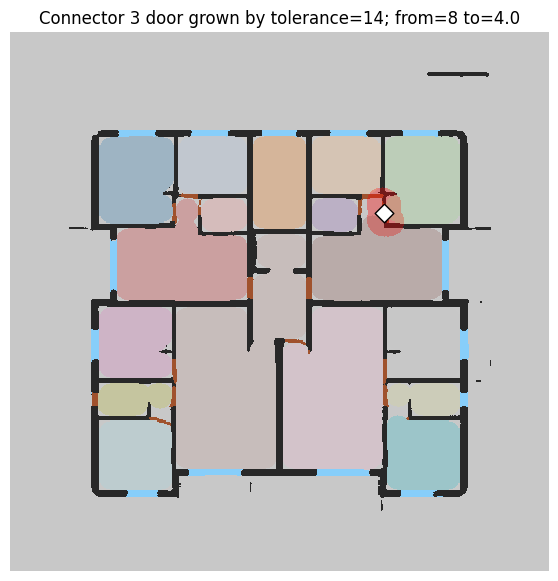

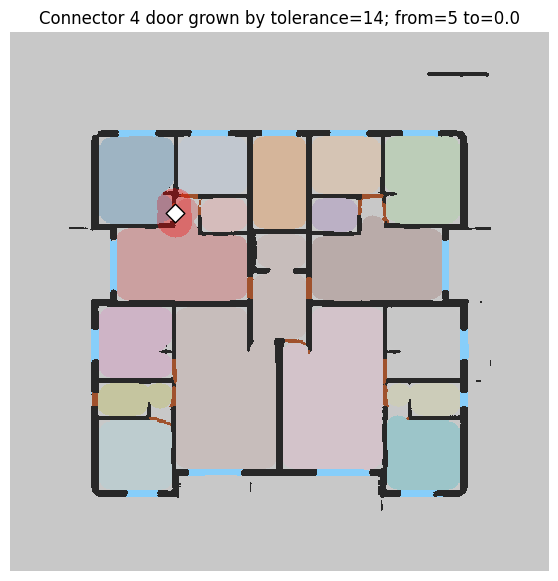

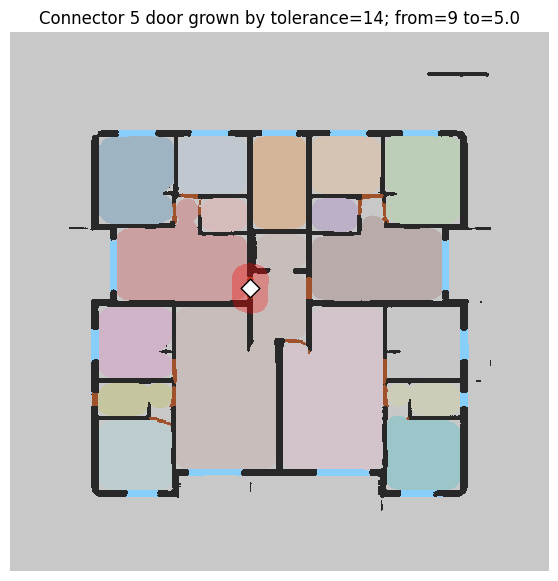

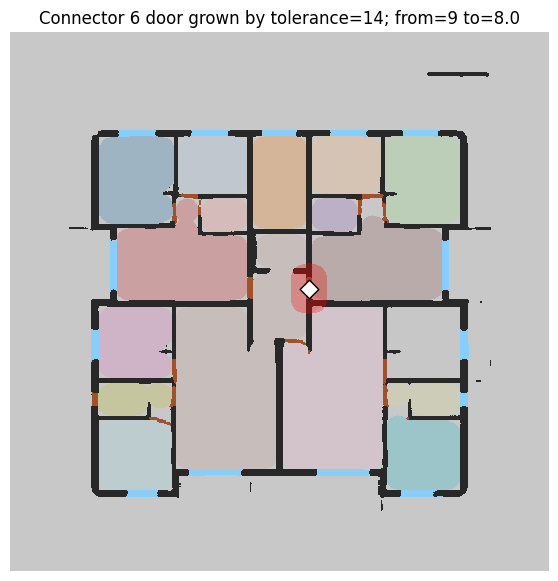

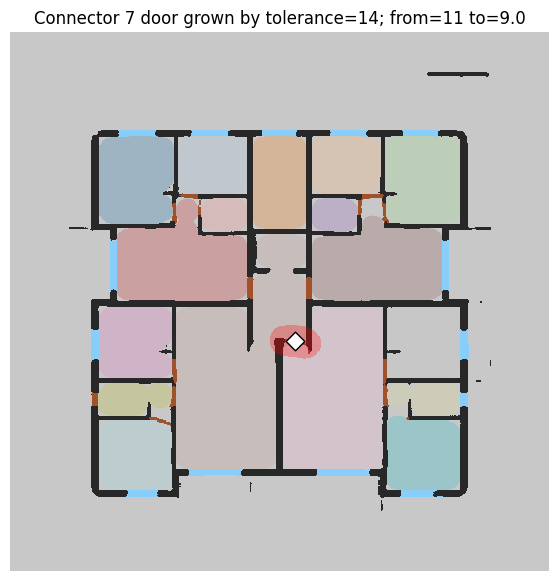

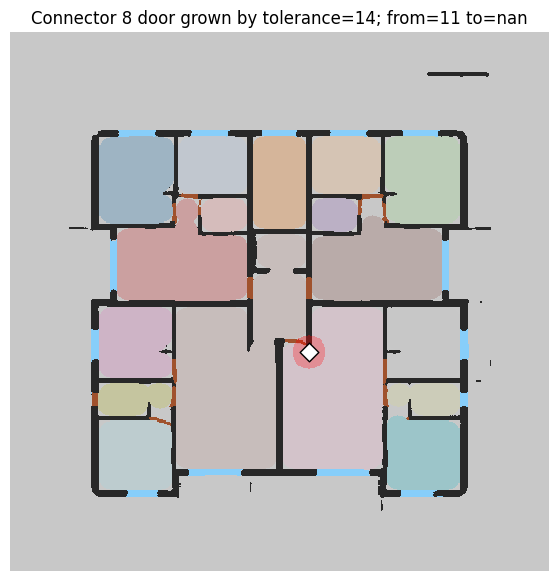

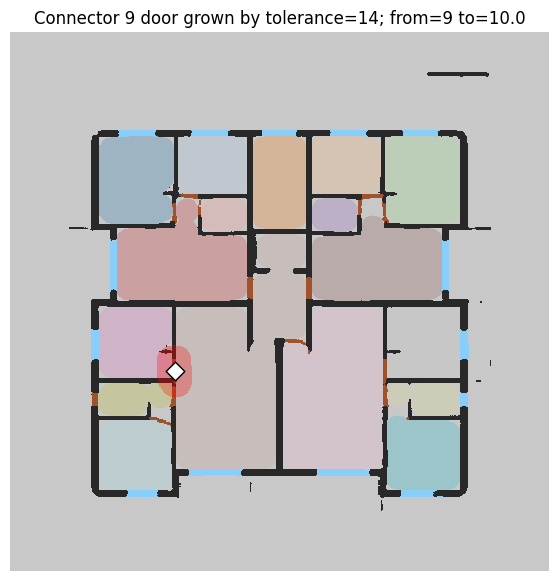

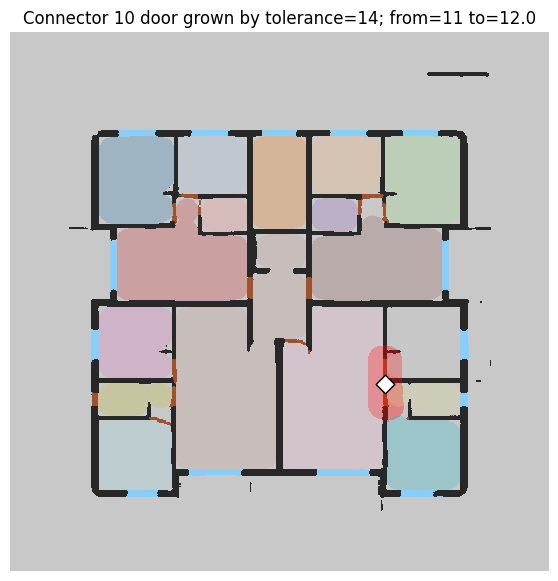

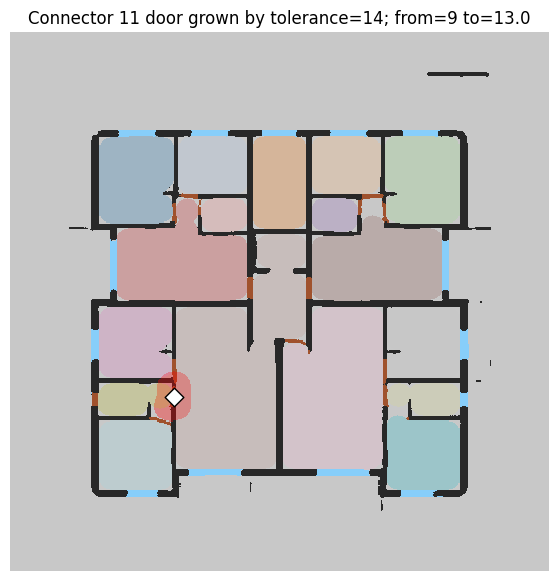

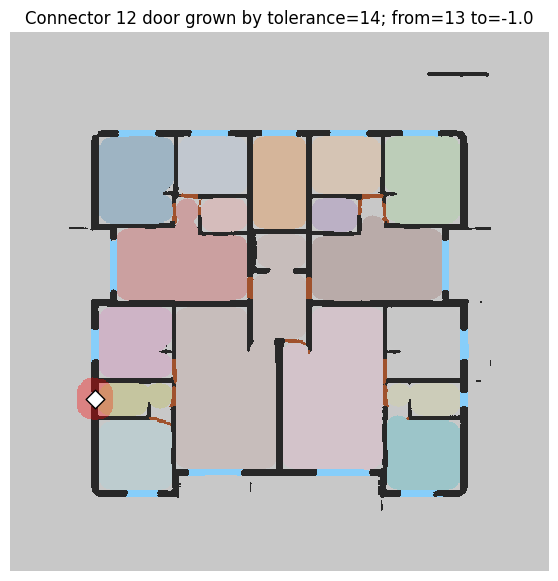

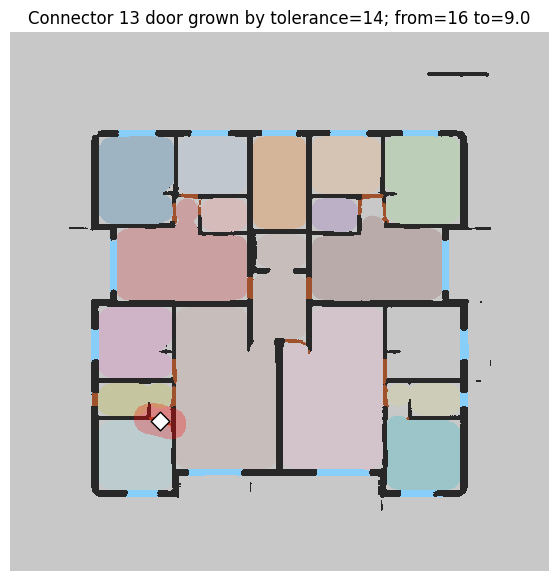

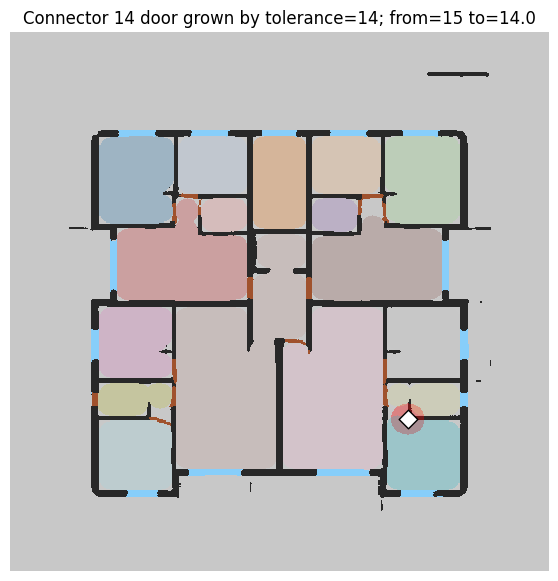

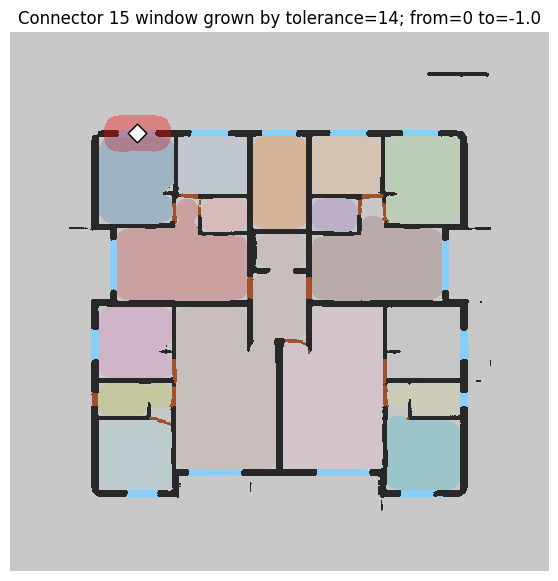

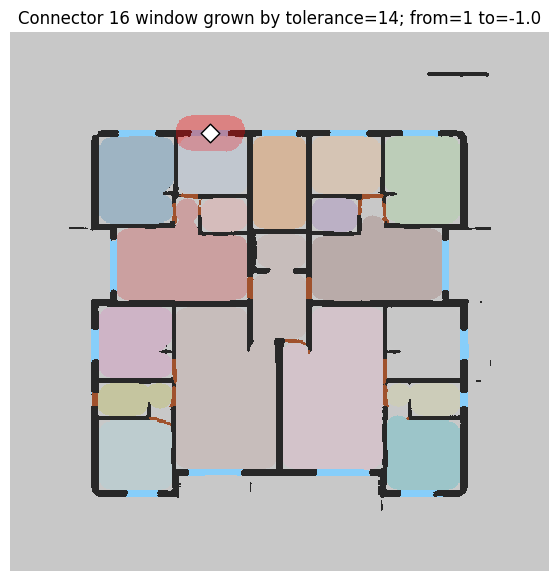

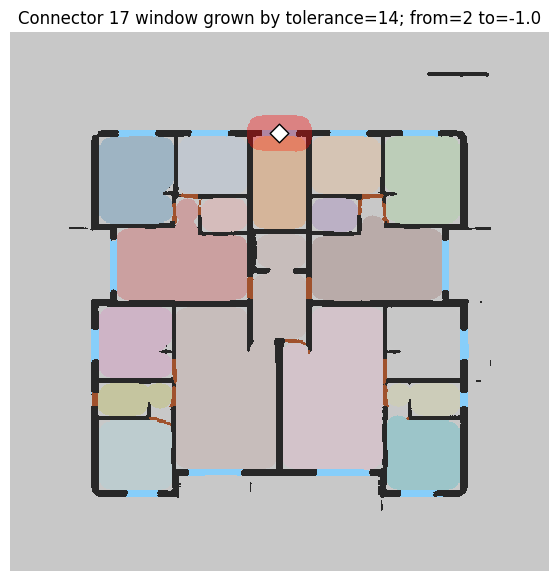

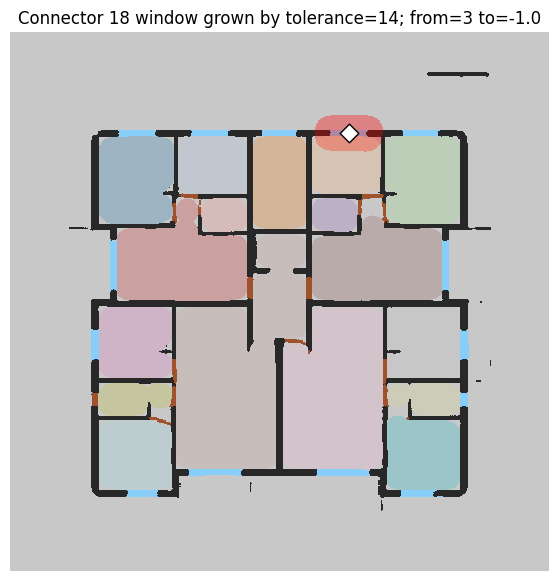

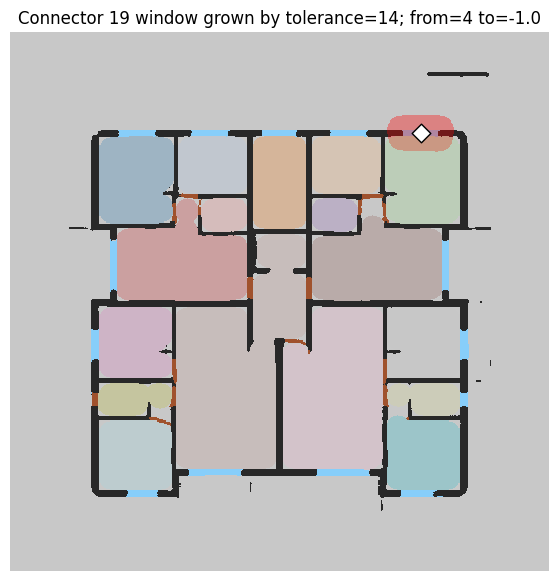

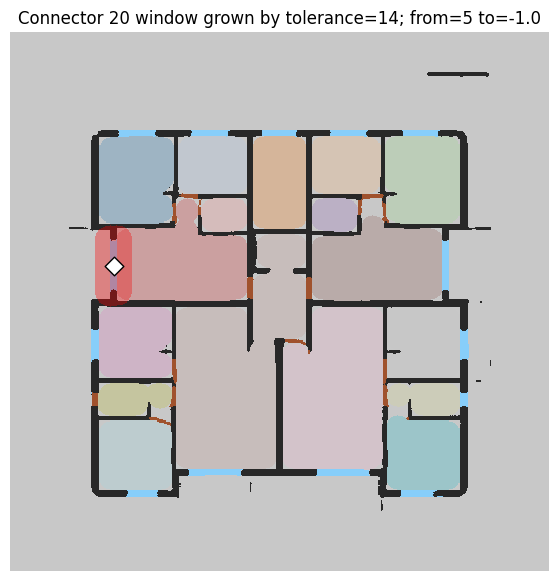

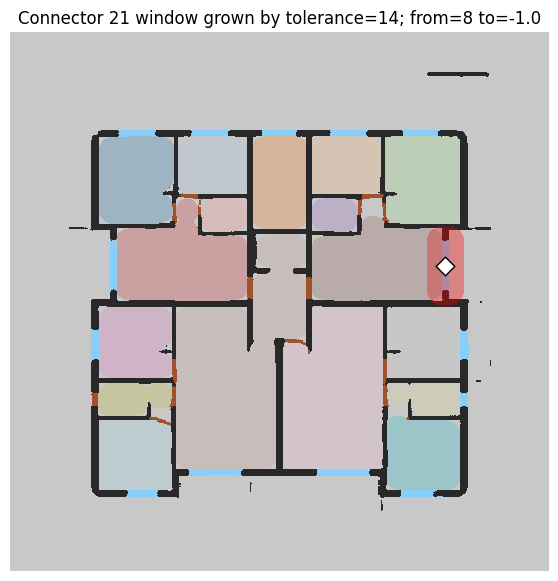

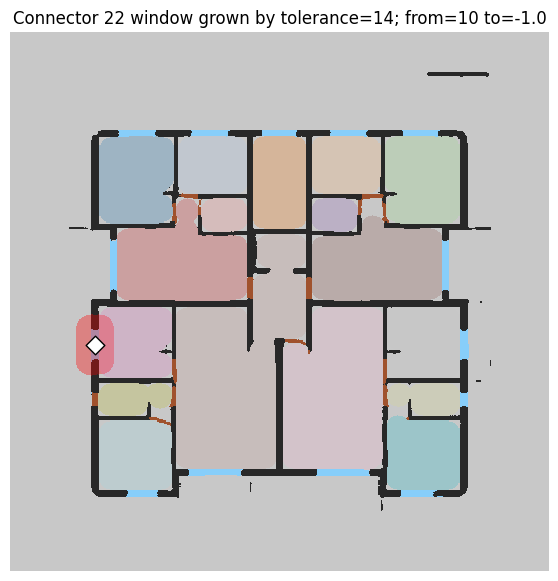

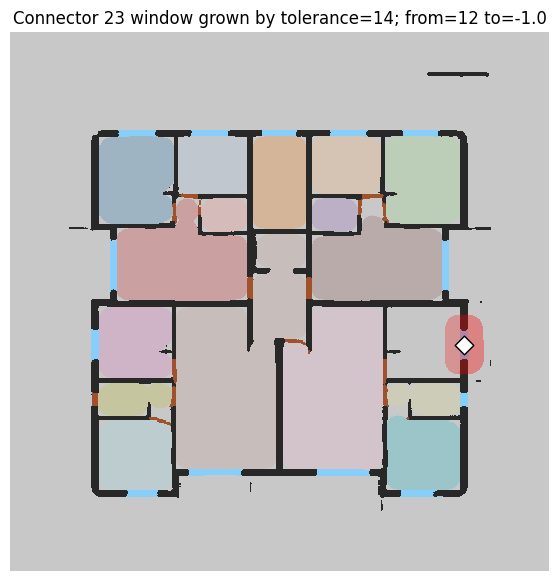

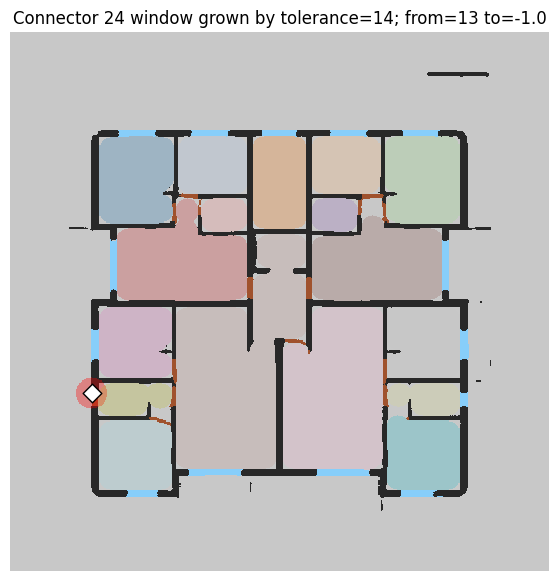

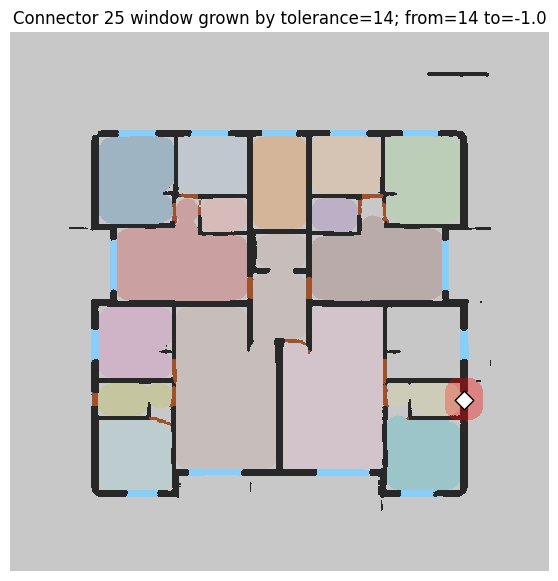

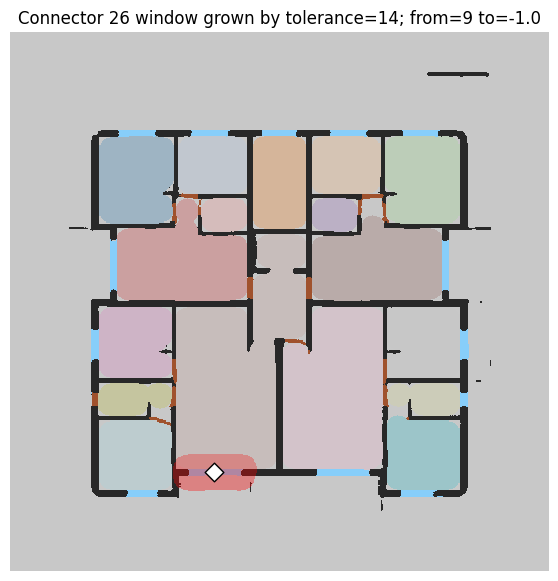

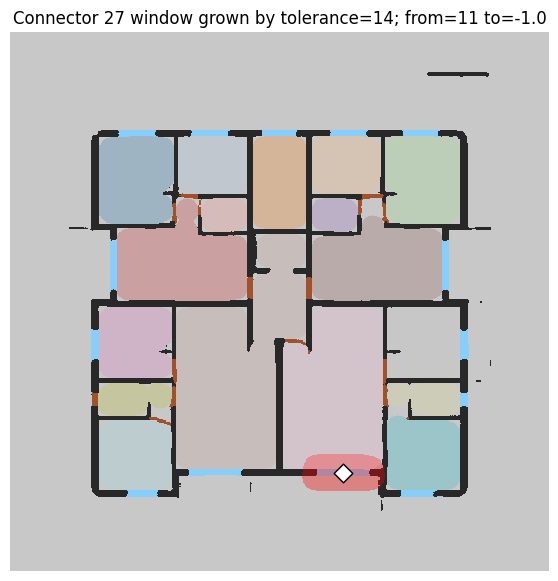

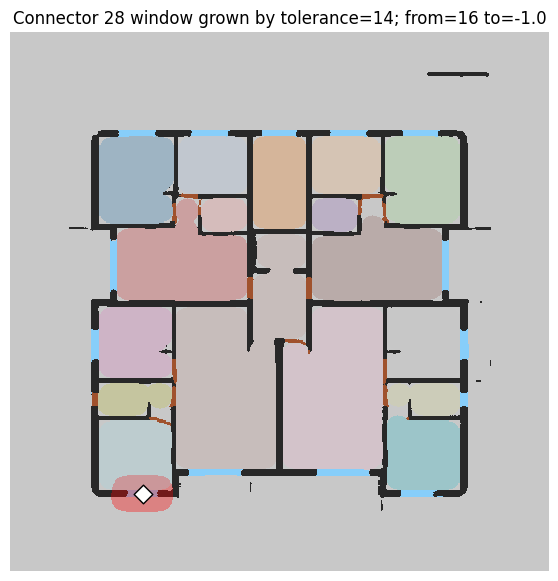

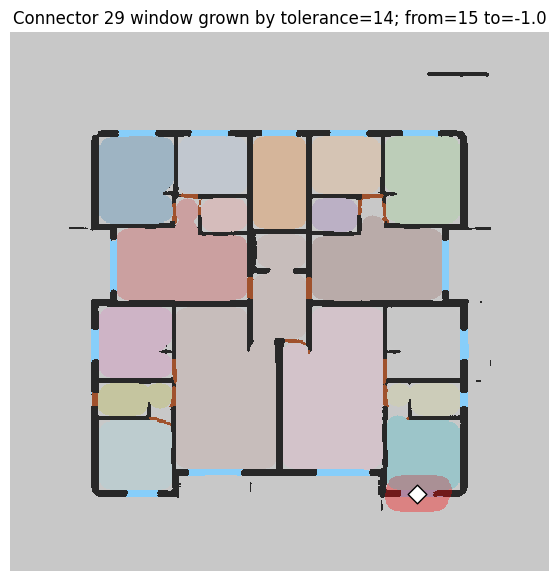

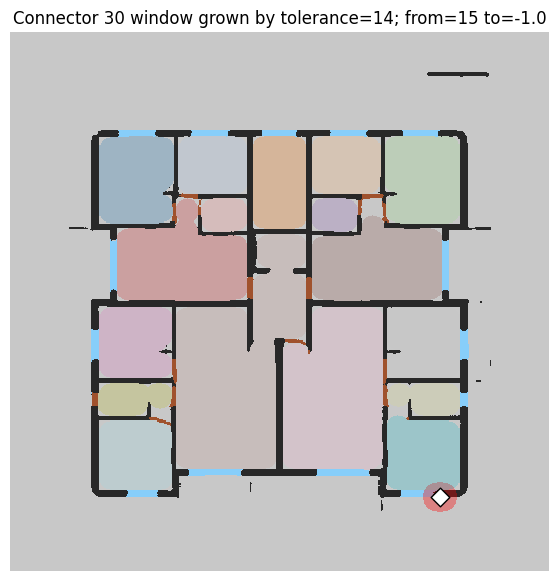

In [38]:
# ============================================================
# 14) Plot connector matching dilation for each connector
# ============================================================
for conn in connectors:
    eid = conn["id"]
    grown = grown_by_connector[eid]
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(mask_to_rgb(cleaned_mask), interpolation="nearest")
    ax.imshow(np.ma.masked_where(~grown, grown), cmap="autumn", alpha=0.35, interpolation="nearest")
    ax.imshow(np.ma.masked_where(room_label_map < 0, room_label_map), cmap="tab20", alpha=0.25, interpolation="nearest")
    cx, cy = conn["centroid_px"]
    ax.scatter([cx], [cy], s=90, marker="D", c="white", edgecolors="black")
    row = edge_table.loc[edge_table["edge_id"] == eid].iloc[0].to_dict()
    ax.set_title(f"Connector {eid} {conn['type']} grown by tolerance={effective_tolerance}; from={row['from']} to={row['to']}")
    ax.axis("off")
    plt.show()


Final internal graph: 17 rooms, 31 edges


,id,name,area_px,centroid_px,bbox_px,contour
0,0,room_0,5594,"[119.19592420450482, 139.86825169824812]","[[85, 99], [156, 99], [156, 182], [85, 182]]","[[89, 102], [85, 107], [86, 176], [95, 181], [..."
1,1,room_1,3452,"[191.9962340672074, 126.10457705677868]","[[160, 99], [225, 99], [225, 154], [160, 154]]","[[161, 105], [160, 146], [164, 151], [214, 153..."
2,2,room_2,4292,"[255.5, 142.5]","[[231, 99], [281, 99], [281, 187], [231, 187]]","[[237, 100], [231, 106], [231, 179], [241, 186..."
3,3,room_3,3438,"[318.76439790575915, 126.00407213496219]","[[287, 99], [352, 99], [352, 154], [287, 154]]","[[288, 104], [287, 146], [291, 151], [340, 153..."
4,4,room_4,5666,"[391.63130956583126, 139.63272149664667]","[[356, 99], [427, 99], [427, 182], [356, 182]]","[[360, 101], [356, 106], [356, 145], [368, 154..."
5,5,room_5,8589,"[161.8432879264175, 218.72383280940738]","[[102, 158], [225, 158], [225, 256], [102, 256]]","[[224, 200], [214, 193], [179, 193], [174, 180..."
6,6,room_6,1265,"[202.7106719367589, 173.38814229249013]","[[181, 158], [225, 158], [225, 190], [181, 190]]","[[181, 166], [182, 182], [188, 188], [212, 189..."
7,7,room_7,1253,"[308.3072625698324, 173.26336791699921]","[[287, 158], [331, 158], [331, 190], [287, 190]]","[[287, 165], [287, 181], [293, 187], [319, 189..."
8,8,room_8,8230,"[349.4618469015796, 220.58371810449574]","[[287, 174], [410, 174], [410, 256], [287, 256]]","[[287, 201], [287, 247], [293, 253], [399, 254..."
9,9,room_9,18088,"[216.10172490048652, 317.1287041132242]","[[158, 192], [281, 192], [281, 415], [158, 415]]","[[276, 194], [235, 199], [248, 225], [231, 237..."


,id,type,label_id,centroid_px,contour,from,to
0,0,door,2,"[170.48611111111111, 155.56944444444446]","[[161, 153], [178, 153], [178, 158], [161, 158]]",1,5.0
1,1,door,2,"[339.6356589147287, 158.86821705426357]","[[331, 154], [354, 154], [354, 173], [331, 173]]",3,7.0
2,2,door,2,"[179.6086956521739, 167.2173913043478]","[[179, 159], [181, 159], [181, 173], [179, 173]]",6,5.0
3,3,door,2,"[355.15942028985506, 171.3913043478261]","[[353, 161], [359, 161], [359, 180], [353, 180]]",8,4.0
4,4,door,2,"[155.97142857142856, 171.57142857142858]","[[154, 162], [158, 162], [158, 181], [154, 181]]",5,0.0
5,5,door,2,"[227.58536585365854, 242.77235772357724]","[[225, 233], [231, 233], [231, 253], [225, 253]]",9,5.0
6,6,door,2,"[283.5, 243.16129032258064]","[[281, 233], [286, 233], [286, 253], [281, 253]]",9,8.0
7,7,door,2,"[270.6666666666667, 293.4074074074074]","[[261, 292], [280, 292], [280, 296], [261, 296]]",11,9.0
8,8,door,2,"[283.5, 303.5]","[[283, 302], [284, 302], [284, 305], [283, 305]]",11,NaN
9,9,door,2,"[155.9673913043478, 321.35869565217394]","[[154, 311], [158, 311], [158, 333], [154, 333]]",9,10.0


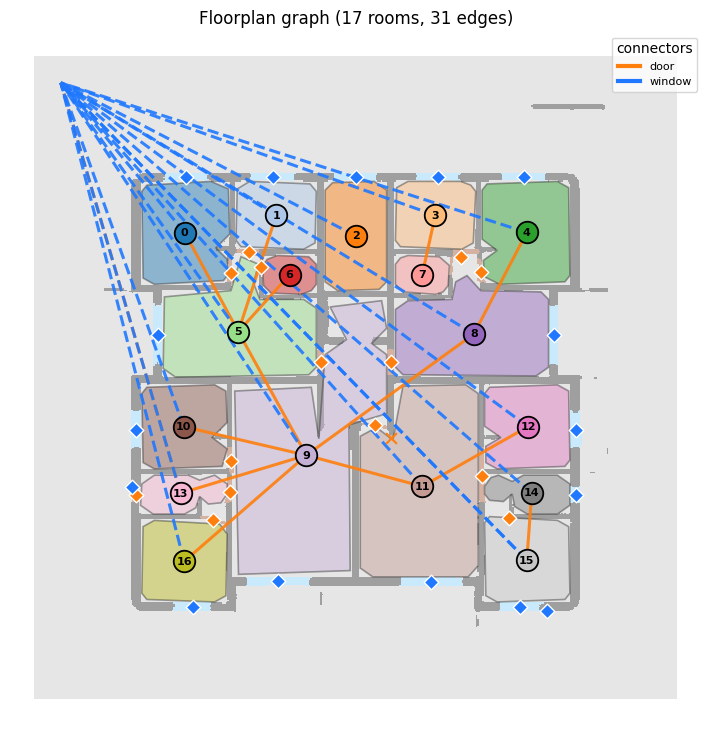

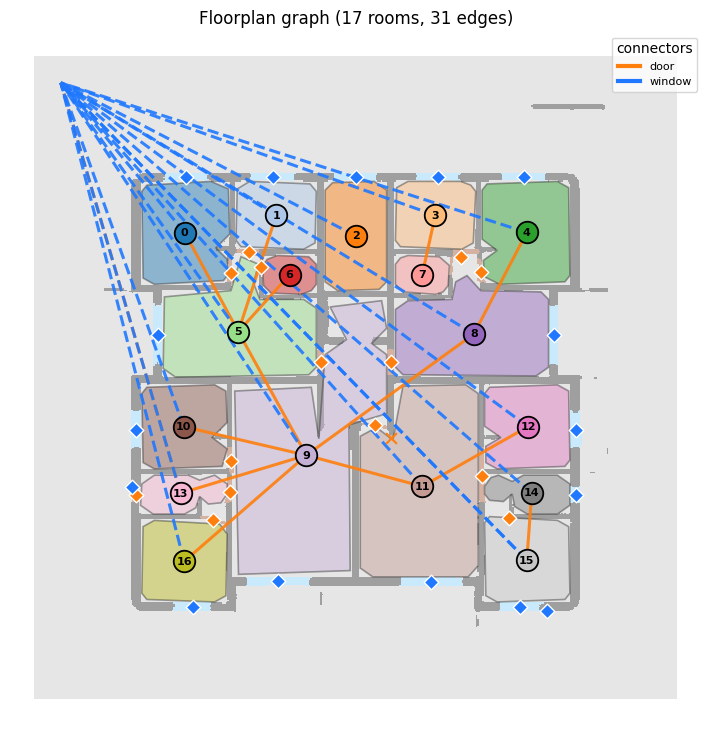

In [39]:
# ============================================================
# 15) Clean graph and plot final internal graph
# ============================================================
def clean_graph(graph, keep_outside=True):
    graph = dict(graph)
    if keep_outside:
        graph["edges"] = [e for e in graph["edges"] if e["from"] is not None]
    else:
        graph["edges"] = [e for e in graph["edges"] if e["from"] is not None and e["to"] is not None and e["to"] != OUTSIDE_ID]
    return graph


def plot_graph(graph, image_size=None, figsize=(9, 9), show_mask=True):
    nodes, edges = graph["nodes"], graph["edges"]
    cleaned = graph.get("cleaned_mask")
    if image_size is None and cleaned is not None:
        image_size = cleaned.shape
    H, W = image_size if image_size else (512, 512)
    edge_colors = {DOOR_ID: "#ff7f0e", WINDOW_ID: "#1f78ff"}
    edge_names = {DOOR_ID: "door", WINDOW_ID: "window"}
    cmap = plt.colormaps["tab20"]

    fig, ax = plt.subplots(figsize=figsize)
    if show_mask and cleaned is not None:
        ax.imshow(mask_to_rgb(cleaned), alpha=0.45, interpolation="nearest")

    outside_xy = (W * 0.04, H * 0.04)
    node_xy = {OUTSIDE_ID: outside_xy}
    for n in nodes:
        cx, cy = n["centroid_px"]
        node_xy[n["id"]] = (cx, cy)
        color = cmap(n["id"] % 20)
        if n.get("contour") and len(n["contour"]) >= 3:
            ax.add_patch(MplPolygon(n["contour"], closed=True, facecolor=color, edgecolor="#333333", alpha=0.45, linewidth=1.2))
        ax.scatter([cx], [cy], s=240, color=color, edgecolors="black", zorder=5, linewidths=1.3)
        ax.text(cx, cy, str(n["id"]), ha="center", va="center", fontsize=8, fontweight="bold", zorder=6)

    for e in edges:
        a = node_xy.get(e.get("from"))
        b = node_xy.get(e.get("to"))
        color = edge_colors.get(e["label_id"], "#555555")
        if a is None:
            continue
        if b is None:
            mx, my = e["centroid_px"]
            ax.scatter([mx], [my], s=60, marker="x", c=color, zorder=7)
            continue
        is_out = e.get("to") == OUTSIDE_ID
        ax.plot([a[0], b[0]], [a[1], b[1]], color=color, lw=2.2, zorder=4, solid_capstyle="round", linestyle="--" if is_out else "-", alpha=0.9)
        mx, my = e["centroid_px"]
        ax.scatter([mx], [my], s=55, marker="D", c=color, edgecolors="white", linewidths=1, zorder=7)

    handles = [Line2D([0], [0], color=c, lw=3, label=edge_names[k]) for k, c in edge_colors.items()]
    ax.legend(handles=handles, title="connectors", loc="upper right", fontsize=8)
    ax.set_xlim(-20, W + 20)
    ax.set_ylim(H + 20, -20)
    ax.set_aspect("equal")
    ax.set_title(f"Floorplan graph ({len(nodes)} rooms, {len(edges)} edges)")
    ax.axis("off")
    plt.show()
    return fig

graph = {
    "nodes": rooms,
    "edges": edges,
    "cleaned_mask": cleaned_mask,
    "outside_mask": outside_mask,
}
graph = clean_graph(graph, keep_outside=KEEP_OUTSIDE_EDGES)
print(f"Final internal graph: {len(graph['nodes'])} rooms, {len(graph['edges'])} edges")
display(pd.DataFrame(graph["nodes"]))
display(pd.DataFrame(graph["edges"]))
plot_graph(graph, image_size=mask.shape, show_mask=True)


In [40]:
# ============================================================
# 16) Export schema helpers
# ============================================================
def round_pt(p):
    return [int(round(p[0])), int(round(p[1]))]


def to_export_schema(graph, image_size, sample_id="sample", scale_px_per_ft=None):
    H, W = image_size
    rooms_out = graph["nodes"]
    edges_out_internal = graph["edges"]
    N = len(rooms_out)

    BUILDING_ID = 0
    room_eid = {r["id"]: r["id"] + 1 for r in rooms_out}
    needs_exterior = any(e.get("to") == OUTSIDE_ID for e in edges_out_internal)
    EXTERIOR_ID = (N + 1) if needs_exterior else None
    full_poly = [[0, 0], [W, 0], [W, H], [0, H]]

    nodes_out = [{
        "id": BUILDING_ID,
        "hierarchy_id": "0",
        "name": "building",
        "label_id": None,
        "type": "building",
        "parent_id": None,
        "bbox_px": full_poly,
        "polygon_px": full_poly,
    }]

    for k, r in enumerate(rooms_out, start=1):
        nodes_out.append({
            "id": room_eid[r["id"]],
            "hierarchy_id": f"0.{k}",
            "name": r.get("name", f"room_{k}"),
            "label_id": None,
            "type": "room",
            "parent_id": BUILDING_ID,
            "area_px": int(r.get("area_px", 0)),
            "centroid_px": round_pt(r["centroid_px"]),
            "bbox_px": r.get("bbox_px"),
            "polygon_px": r.get("contour"),
        })

    if needs_exterior:
        nodes_out.append({
            "id": EXTERIOR_ID,
            "hierarchy_id": f"0.{N + 1}",
            "name": "exterior",
            "label_id": BACKGROUND_ID,
            "type": "exterior",
            "parent_id": None,
            "bbox_px": full_poly,
            "polygon_px": None,
        })

    schema_edges, warnings = [], []
    for r in rooms_out:
        schema_edges.append({"from_id": BUILDING_ID, "to_id": room_eid[r["id"]], "relationship": "contains"})

    for e in edges_out_internal:
        if e["from"] is None:
            warnings.append("connector touched no room (dropped)")
            continue
        ctype = LABELS.get(e["label_id"], "connector")
        center = round_pt(e["centroid_px"])
        if e["to"] == OUTSIDE_ID:
            rel = "entry_to" if e["label_id"] == DOOR_ID else "opens_to"
            efrom, eto = room_eid[e["from"]], EXTERIOR_ID
        elif e["to"] is None:
            continue
        else:
            rel = "connected_to"
            efrom, eto = room_eid[e["from"]], room_eid[e["to"]]
        schema_edges.append({"from_id": efrom, "to_id": eto, "relationship": rel, "connection_type": ctype, "center_px": center})

    present = sorted({int(v) for v in np.unique(graph["cleaned_mask"])})
    return {
        "sample_id": sample_id,
        "graph_type": "room_connectivity_graph_4class",
        "apartment_mix": [],
        "image_size_wh": [int(W), int(H)],
        "scale_px_per_ft": scale_px_per_ft,
        "nodes": nodes_out,
        "edges": schema_edges,
        "unique_label_ids": present,
        "unique_classes": [LABELS.get(i, str(i)) for i in present],
        "rule_validation": {
            "valid": N > 0,
            "errors": [] if N > 0 else ["no rooms detected"],
            "warnings": sorted(set(warnings)),
        },
        "project_type": "layout_graph",
        "units": [],
        "rooms": [n["id"] for n in nodes_out if n["type"] == "room"],
        "unit_masks": [],
        "access_points": [e for e in schema_edges if e.get("relationship") in ("entry_to", "opens_to")],
    }


In [41]:
# ============================================================
# 17) Create export JSON object and inspect it before saving
# ============================================================
export_data = to_export_schema(graph, image_size=mask.shape, sample_id=SAMPLE_ID)
print(json.dumps({
    "sample_id": export_data["sample_id"],
    "image_size_wh": export_data["image_size_wh"],
    "node_count": len(export_data["nodes"]),
    "edge_count": len(export_data["edges"]),
    "rule_validation": export_data["rule_validation"],
}, indent=2))
display(pd.DataFrame(export_data["nodes"]))
display(pd.DataFrame(export_data["edges"]))


{
  "sample_id": "plan_3_mask",
  "image_size_wh": [
    512,
    512
  ],
  "node_count": 19,
  "edge_count": 47,
  "rule_validation": {
    "valid": true,
    "errors": [],
    "warnings": []
  }
}


,id,hierarchy_id,name,label_id,type,parent_id,bbox_px,polygon_px,area_px,centroid_px
0,0,0,building,NaN,building,NaN,"[[0, 0], [512, 0], [512, 512], [0, 512]]","[[0, 0], [512, 0], [512, 512], [0, 512]]",NaN,NaN
1,1,0.1,room_0,NaN,room,0.0,"[[85, 99], [156, 99], [156, 182], [85, 182]]","[[89, 102], [85, 107], [86, 176], [95, 181], [...",5594.0,"[119, 140]"
2,2,0.2,room_1,NaN,room,0.0,"[[160, 99], [225, 99], [225, 154], [160, 154]]","[[161, 105], [160, 146], [164, 151], [214, 153...",3452.0,"[192, 126]"
3,3,0.3,room_2,NaN,room,0.0,"[[231, 99], [281, 99], [281, 187], [231, 187]]","[[237, 100], [231, 106], [231, 179], [241, 186...",4292.0,"[256, 142]"
4,4,0.4,room_3,NaN,room,0.0,"[[287, 99], [352, 99], [352, 154], [287, 154]]","[[288, 104], [287, 146], [291, 151], [340, 153...",3438.0,"[319, 126]"
5,5,0.5,room_4,NaN,room,0.0,"[[356, 99], [427, 99], [427, 182], [356, 182]]","[[360, 101], [356, 106], [356, 145], [368, 154...",5666.0,"[392, 140]"
6,6,0.6,room_5,NaN,room,0.0,"[[102, 158], [225, 158], [225, 256], [102, 256]]","[[224, 200], [214, 193], [179, 193], [174, 180...",8589.0,"[162, 219]"
7,7,0.7,room_6,NaN,room,0.0,"[[181, 158], [225, 158], [225, 190], [181, 190]]","[[181, 166], [182, 182], [188, 188], [212, 189...",1265.0,"[203, 173]"
8,8,0.8,room_7,NaN,room,0.0,"[[287, 158], [331, 158], [331, 190], [287, 190]]","[[287, 165], [287, 181], [293, 187], [319, 189...",1253.0,"[308, 173]"
9,9,0.9,room_8,NaN,room,0.0,"[[287, 174], [410, 174], [410, 256], [287, 256]]","[[287, 201], [287, 247], [293, 253], [399, 254...",8230.0,"[349, 221]"


,from_id,to_id,relationship,connection_type,center_px
0,0,1,contains,NaN,NaN
1,0,2,contains,NaN,NaN
2,0,3,contains,NaN,NaN
3,0,4,contains,NaN,NaN
4,0,5,contains,NaN,NaN
5,0,6,contains,NaN,NaN
6,0,7,contains,NaN,NaN
7,0,8,contains,NaN,NaN
8,0,9,contains,NaN,NaN
9,0,10,contains,NaN,NaN


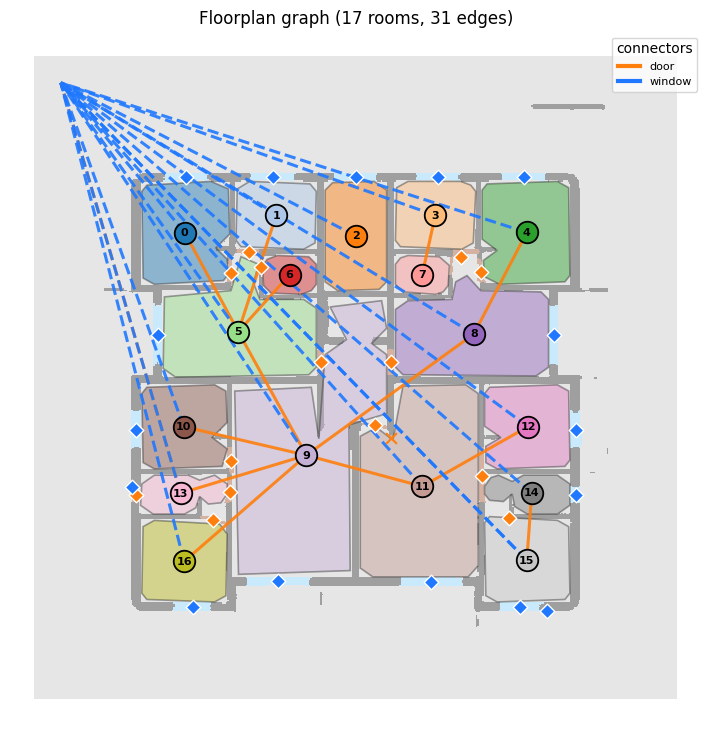

Saved graph JSON: plan_3_mask/plan_3_mask/plan_3_mask_graph.json
Saved cleaned NPY: plan_3_mask/plan_3_mask/plan_3_mask_cleaned.npy
Saved cleaned PNG: plan_3_mask/plan_3_mask/plan_3_mask_cleaned.png
Saved graph PNG: plan_3_mask/plan_3_mask/plan_3_mask_graph.png


In [42]:
# ============================================================
# 18) Save outputs
# ============================================================
graph_json_path = Path(str(OUT_BASE) + "_graph.json")
cleaned_npy_path = Path(str(OUT_BASE) + "_cleaned.npy")
cleaned_png_path = Path(str(OUT_BASE) + "_cleaned.png")
graph_png_path = Path(str(OUT_BASE) + "_graph.png")

with graph_json_path.open("w") as f:
    json.dump(export_data, f, indent=2)
np.save(cleaned_npy_path, cleaned_mask.astype(np.uint8))
Image.fromarray(mask_to_rgb(cleaned_mask)).save(cleaned_png_path)

# Save final plot too
fig = plot_graph(graph, image_size=mask.shape, show_mask=True)
fig.savefig(graph_png_path, dpi=130, bbox_inches="tight")

print(f"Saved graph JSON: {graph_json_path}")
print(f"Saved cleaned NPY: {cleaned_npy_path}")
print(f"Saved cleaned PNG: {cleaned_png_path}")
print(f"Saved graph PNG: {graph_png_path}")
